In [1]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results folder: {OUT_DIR}")

Project root: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking
Results folder: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results


# Cost function experiment

This notebook searches for robust cost-function settings for two assignment stages:

1. **Peak-to-peak linking:** connect localized detections between frames into candidate trajectories.
2. **Trajectory-to-trajectory assignment:** assign reconstructed trajectories to fragmented ground truth for evaluation.

Ground-truth trajectories are deliberately converted into shorter temporal fragments before assignment. The evaluation therefore contains GT tracks that do not all start at the first frame, and some original particles are represented by multiple GT fragments. This makes the trajectory-assignment step closer to realistic partial-track evaluation.

Peak-to-peak metrics are kept as in the previous version: HOTA, MOTA, MOTP, ID switches, fragmentations, coverage, localization error, and exact consecutive-frame link diagnostics. Trajectory-to-trajectory panels are restricted to link F1, link recall, mean GT coverage, and median localization error.

In [2]:
import copy
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from IPython.display import display

from helpers.helpersSimulation import Simulator
from helpers.helpersTracking import (
    extract_peaks,
    track_from_peaks,
    track_peaks_to_trajectories,
    PeakToPeak,
    DistanceTerm,
    IntensityTerm,
    SigmaTerm,
)
from helpers.helpersAssignment import (
    TrajToTraj,
    MeanPositionDistanceTerm,
    LengthDifferenceTerm,
    StartFrameDifferenceTerm,
    assign_trajectories,
)
from helpers.helpersPlotting import linear_trajectories_visualizer

# British-spelling alias for report/notebook text.
linear_trajectories_visualiser = linear_trajectories_visualizer

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
})

## Experiment design

In [ ]:
N_SEEDS = 2
SEEDS = list(range(N_SEEDS))

NFRAMES = 50
NPOSFRAME = 10

DIFFICULTY_SETUPS = [
    {"setup": "S1", "nparticles": 5, "intensity_mean": 800, "intensity_std": 50},
    {"setup": "S2", "nparticles": 10, "intensity_mean": 700, "intensity_std": 100},
    {"setup": "S3", "nparticles": 15, "intensity_mean": 600, "intensity_std": 150},
    {"setup": "S4", "nparticles": 20, "intensity_mean": 550, "intensity_std": 200},
    {"setup": "S5", "nparticles": 25, "intensity_mean": 500, "intensity_std": 300},
]

DIFFICULTY_LABELS = [
    f"S{cfg['setup']} (N={cfg['nparticles']}, I={cfg['intensity_mean']}+/-{cfg['intensity_std']})"
    for cfg in DIFFICULTY_SETUPS
]

D_LIST = [
    (0.02, 0.16),
    (0.08, 0.14),
    (0.25, 0.14),
    (0.75, 0.14),
    (2.00, 0.14),
    (4.50, 0.14),
    (8.00, 0.14),
]

SIM_CONFIG_BASE = {
    "nparticles": None,
    "nframes": NFRAMES,
    "nposframe": NPOSFRAME,
    "D_list": D_LIST,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0), # isotropic diffusion
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": None,
    "intensity_std": None,
    "sigma_mean": 1.0,
    "sigma_std": 0.2,
}

IMAGE_CONFIG_BASE = {}

TRACKING_KWARGS = {
    "mode": "localization",
    "detection_threshold": 400,
    "r_squared_threshold": 0.45,
    "max_distance": 8.0,
    "min_length": 5,
    "max_gap": 1,
    "algo_peak2peak": "hungarian",
    "algo_traj2traj": "hungarian",
}

PEAK_NORMS = {
    "distance": TRACKING_KWARGS["max_distance"],
    "intensity": 700.0,
    "sigma": 0.75,
}
TRAJ_NORMS = {
    "position": TRACKING_KWARGS["max_distance"],
    "length": 10.0,
    "start_frame": 5.0,
}

TRUTH_MATCH_TOLERANCE_PX = 3.0
PEAK_SELECTION_METRIC = "hota"
TRAJ_SELECTION_METRIC = "link_f1"
CACHE_VERSION = "fragmented_gt_v2"
FORCE_RERUN = False

# keep unfragmented GTs but that may be shorter and start later than the first frame
GT_FRAGMENTATION = {
    "enabled": True,
    "min_fragment_length": 10,
    "max_fragments_per_gt": 1,
    "max_start_drop_frac": 0.25,
    "max_end_drop_frac": 0.20,
    "gap_range": (1, 5),
}

REQUIRED_RESULT_COLUMNS = {
    "hota",
    "mota",
    "motp_px",
    "id_switches",
    "fragmentations",
    "mean_fragmentations_per_gt",
    "link_f1",
    "link_recall",
    "mean_coverage",
    "median_position_error_px",
    "cache_version",
}

RESULT_STEM = "CostExperiment_difficulty_intensity"
RESULT_PATHS = {
    "peak": OUT_DIR / f"{RESULT_STEM}_peak2peak_results.csv",
    "traj": OUT_DIR / f"{RESULT_STEM}_traj2traj_results.csv",
    "summary": OUT_DIR / f"{RESULT_STEM}_recommendations.csv",
    "peak_figure_png": OUT_DIR / f"{RESULT_STEM}_tracking_metrics_peak.png",
    "traj_figure_png": OUT_DIR / f"{RESULT_STEM}_tracking_metrics_traj.png",
    "gt_viz_png": OUT_DIR / f"{RESULT_STEM}_fragmented_gt.png",
    "gt_viz_pdf": OUT_DIR / f"{RESULT_STEM}_fragmented_gt.pdf",
    "best_viz_png": OUT_DIR / f"{RESULT_STEM}_best_trajectories_vs_gt.png",
    "best_viz_pdf": OUT_DIR / f"{RESULT_STEM}_best_trajectories_vs_gt.pdf",
}

print(f"Simulations: {len(SEEDS) * len(DIFFICULTY_SETUPS)}")
print(f"Frames per simulation: {NFRAMES}, positions per frame: {NPOSFRAME}")

Simulations: 10
Frames per simulation: 50, positions per frame: 10


## Cost grids

In [4]:
PEAK_COST_SPECS = [
    {"name": "distance_only", "family": "ablation", "distance": 1.00, "intensity": 0.00, "sigma": 0.00},
    {"name": "intensity_only", "family": "ablation", "distance": 0.00, "intensity": 1.00, "sigma": 0.00},
    {"name": "sigma_only", "family": "ablation", "distance": 0.00, "intensity": 0.00, "sigma": 1.00},
    {"name": "dist_int_90_10", "family": "distance_intensity", "distance": 0.90, "intensity": 0.10, "sigma": 0.00},
    {"name": "dist_int_75_25", "family": "distance_intensity", "distance": 0.75, "intensity": 0.25, "sigma": 0.00},
    {"name": "dist_int_60_40", "family": "distance_intensity", "distance": 0.60, "intensity": 0.40, "sigma": 0.00},
    {"name": "dist_sig_90_10", "family": "distance_sigma", "distance": 0.90, "intensity": 0.00, "sigma": 0.10},
    {"name": "dist_sig_75_25", "family": "distance_sigma", "distance": 0.75, "intensity": 0.00, "sigma": 0.25},
    {"name": "dist_sig_60_40", "family": "distance_sigma", "distance": 0.60, "intensity": 0.00, "sigma": 0.40},
    {"name": "dist_meta_80_10_10", "family": "all_terms", "distance": 0.80, "intensity": 0.10, "sigma": 0.10},
    {"name": "dist_meta_70_20_10", "family": "all_terms", "distance": 0.70, "intensity": 0.20, "sigma": 0.10},
    {"name": "dist_meta_50_40_10", "family": "all_terms", "distance": 0.50, "intensity": 0.40, "sigma": 0.10},
    {"name": "equal_all", "family": "all_terms", "distance": 1/3, "intensity": 1/3, "sigma": 1/3},
]

TRAJ_COST_SPECS = [
    {"name": "position_only", "family": "ablation", "position": 1.00, "length": 0.00, "start_frame": 0.00},
    {"name": "length_only", "family": "ablation", "position": 0.00, "length": 1.00, "start_frame": 0.00},
    {"name": "start_only", "family": "ablation", "position": 0.00, "length": 0.00, "start_frame": 1.00},
    {"name": "pos_len_90_10", "family": "position_length", "position": 0.90, "length": 0.10, "start_frame": 0.00},
    {"name": "pos_len_75_25", "family": "position_length", "position": 0.75, "length": 0.25, "start_frame": 0.00},
    {"name": "pos_len_60_40", "family": "position_length", "position": 0.60, "length": 0.40, "start_frame": 0.00},
    {"name": "pos_start_90_10", "family": "position_start", "position": 0.90, "length": 0.00, "start_frame": 0.10},
    {"name": "pos_start_75_25", "family": "position_start", "position": 0.75, "length": 0.00, "start_frame": 0.25},
    {"name": "pos_start_60_40", "family": "position_start", "position": 0.60, "length": 0.00, "start_frame": 0.40},
    {"name": "pos_meta_80_10_10", "family": "all_terms", "position": 0.80, "length": 0.10, "start_frame": 0.10},
    {"name": "pos_meta_70_20_10", "family": "all_terms", "position": 0.70, "length": 0.20, "start_frame": 0.10},
    {"name": "pos_meta_60_20_20", "family": "all_terms", "position": 0.60, "length": 0.20, "start_frame": 0.20},
    {"name": "equal_all", "family": "all_terms", "position": 1/3, "length": 1/3, "start_frame": 1/3},
]

def build_peak_cost(spec):
    terms = {}
    if spec.get("distance", 0) > 0:
        terms["distance"] = DistanceTerm(weight=float(spec["distance"]), norm=PEAK_NORMS["distance"])
    if spec.get("intensity", 0) > 0:
        terms["intensity"] = IntensityTerm(weight=float(spec["intensity"]), norm=PEAK_NORMS["intensity"])
    if spec.get("sigma", 0) > 0:
        terms["sigma"] = SigmaTerm(weight=float(spec["sigma"]), norm=PEAK_NORMS["sigma"])
    return PeakToPeak(terms=terms)

def build_traj_cost(spec):
    terms = {}
    if spec.get("position", 0) > 0:
        terms["position"] = MeanPositionDistanceTerm(
            weight=float(spec["position"]),
            norm=TRAJ_NORMS["position"],
            invalid_cost=1e6,
        )
    if spec.get("length", 0) > 0:
        terms["length"] = LengthDifferenceTerm(weight=float(spec["length"]), norm=TRAJ_NORMS["length"])
    if spec.get("start_frame", 0) > 0:
        terms["start_frame"] = StartFrameDifferenceTerm(
            weight=float(spec["start_frame"]),
            norm=TRAJ_NORMS["start_frame"],
        )
    return TrajToTraj(terms=terms)

FIXED_TRAJ_EVALUATOR_SPEC = next(spec for spec in TRAJ_COST_SPECS if spec["name"] == "position_only")
FIXED_TRAJ_EVALUATOR = build_traj_cost(FIXED_TRAJ_EVALUATOR_SPEC)

display(pd.DataFrame(PEAK_COST_SPECS))
display(pd.DataFrame(TRAJ_COST_SPECS))

,name,family,distance,intensity,sigma
0,distance_only,ablation,1.000000,0.000000,0.000000
1,intensity_only,ablation,0.000000,1.000000,0.000000
2,sigma_only,ablation,0.000000,0.000000,1.000000
3,dist_int_90_10,distance_intensity,0.900000,0.100000,0.000000
4,dist_int_75_25,distance_intensity,0.750000,0.250000,0.000000
5,dist_int_60_40,distance_intensity,0.600000,0.400000,0.000000
6,dist_sig_90_10,distance_sigma,0.900000,0.000000,0.100000
7,dist_sig_75_25,distance_sigma,0.750000,0.000000,0.250000
8,dist_sig_60_40,distance_sigma,0.600000,0.000000,0.400000
9,dist_meta_80_10_10,all_terms,0.800000,0.100000,0.100000


,name,family,position,length,start_frame
0,position_only,ablation,1.000000,0.000000,0.000000
1,length_only,ablation,0.000000,1.000000,0.000000
2,start_only,ablation,0.000000,0.000000,1.000000
3,pos_len_90_10,position_length,0.900000,0.100000,0.000000
4,pos_len_75_25,position_length,0.750000,0.250000,0.000000
5,pos_len_60_40,position_length,0.600000,0.400000,0.000000
6,pos_start_90_10,position_start,0.900000,0.000000,0.100000
7,pos_start_75_25,position_start,0.750000,0.000000,0.250000
8,pos_start_60_40,position_start,0.600000,0.000000,0.400000
9,pos_meta_80_10_10,all_terms,0.800000,0.100000,0.100000


## Metrics

In [ ]:
def finite_mean(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(np.mean(values)) if len(values) else np.nan

def finite_median(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(np.median(values)) if len(values) else np.nan

def finite_sem(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) <= 1:
        return np.nan
    return float(np.std(values, ddof=1) / np.sqrt(len(values)))

def valid_gt_id(gid, gt_by_id):
    return gid is not None and gid != -1 and gid in gt_by_id

def edge_counter(trajectories, require_valid_gt=True, gt_by_id=None):
    edges = Counter()
    for traj in trajectories:
        gid = traj.id
        if require_valid_gt and not valid_gt_id(gid, gt_by_id):
            continue
        frames = sorted(traj.frames())
        for f0, f1 in zip(frames[:-1], frames[1:]):
            if f1 == f0 + 1:
                edges[(int(gid), int(f0), int(f1))] += 1
    return edges

def precision_recall_f1(pred_edges, gt_edges):
    tp = sum(min(count, gt_edges.get(edge, 0)) for edge, count in pred_edges.items())
    fp = sum(pred_edges.values()) - tp
    fn = sum(gt_edges.values()) - tp
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
        else np.nan
    )
    return precision, recall, f1, tp, fp, fn

def assigned_position_errors(trajectories, gt_by_id):
    errors = []
    for traj in trajectories:
        if not valid_gt_id(traj.id, gt_by_id):
            continue
        gt_traj = gt_by_id[traj.id]
        for frame in traj.frames():
            pos = traj.get_position_at_frame(frame)
            gt_pos = gt_traj.get_position_at_frame(frame)
            if pos is None or gt_pos is None:
                continue
            errors.append(float(np.linalg.norm(np.asarray(pos) - np.asarray(gt_pos))))
    return np.asarray(errors, dtype=float)

def coverage_and_fragments(trajectories, trajectories_gt):
    gt_by_id = {traj.id: traj for traj in trajectories_gt if traj.id is not None and traj.length() > 0}
    recovered_frames = {gid: set() for gid in gt_by_id}
    fragment_counts = {gid: 0 for gid in gt_by_id}
    assigned_tracks = 0
    unassigned_tracks = 0

    for traj in trajectories:
        if traj.length() == 0:
            continue
        if not valid_gt_id(traj.id, gt_by_id):
            unassigned_tracks += 1
            continue
        assigned_tracks += 1
        fragment_counts[traj.id] += 1
        gt_traj = gt_by_id[traj.id]
        for frame in traj.frames():
            if gt_traj.get_position_at_frame(frame) is not None:
                recovered_frames[traj.id].add(frame)

    coverage = []
    fragments = []
    for gid, gt_traj in gt_by_id.items():
        coverage.append(len(recovered_frames[gid]) / gt_traj.length())
        fragments.append(fragment_counts[gid])

    return {
        "coverage": np.asarray(coverage, dtype=float),
        "fragments": np.asarray(fragments, dtype=float),
        "assigned_tracks": assigned_tracks,
        "unassigned_tracks": unassigned_tracks,
    }

def detections_by_frame(trajectories, identity="track"):
    by_frame = {}
    for track_idx, traj in enumerate(trajectories):
        if traj.length() == 0:
            continue
        det_id = track_idx if identity == "track" else traj.id
        if identity == "gt" and (det_id is None or det_id == -1):
            continue
        for frame in traj.frames():
            pos = traj.get_position_at_frame(frame)
            if pos is None:
                continue
            by_frame.setdefault(int(frame), []).append({
                "id": det_id,
                "pos": np.asarray(pos, dtype=float),
            })
    return by_frame

def match_detections_by_frame(trajectories, trajectories_gt, tolerance_px=TRUTH_MATCH_TOLERANCE_PX):
    pred_by_frame = detections_by_frame(trajectories, identity="track")
    gt_by_frame = detections_by_frame(trajectories_gt, identity="gt")
    total_pred = sum(len(v) for v in pred_by_frame.values())
    total_gt = sum(len(v) for v in gt_by_frame.values())
    match_rows = []

    for frame in sorted(set(pred_by_frame) | set(gt_by_frame)):
        preds = pred_by_frame.get(frame, [])
        gts = gt_by_frame.get(frame, [])
        if not preds or not gts:
            continue

        cost = np.empty((len(preds), len(gts)), dtype=float)
        for i, pred in enumerate(preds):
            for j, gt in enumerate(gts):
                cost[i, j] = float(np.linalg.norm(pred["pos"] - gt["pos"]))

        row_ind, col_ind = linear_sum_assignment(cost)
        for i, j in zip(row_ind, col_ind):
            error_px = float(cost[i, j])
            if error_px <= tolerance_px:
                match_rows.append({
                    "frame": int(frame),
                    "gt_id": gts[j]["id"],
                    "track_id": preds[i]["id"],
                    "error_px": error_px,
                })

    return pd.DataFrame(match_rows), total_pred, total_gt

def fragmentation_count(gt_frames, matched_frames):
    matched_frames = set(matched_frames)
    was_matched = False
    has_been_matched = False
    n_fragments = 0

    for frame in sorted(gt_frames):
        is_matched = frame in matched_frames
        if is_matched and has_been_matched and not was_matched:
            n_fragments += 1
        if is_matched:
            has_been_matched = True
        was_matched = is_matched

    return n_fragments

def tracking_event_metrics(trajectories, trajectories_gt, tolerance_px=TRUTH_MATCH_TOLERANCE_PX):
    matches, total_pred, total_gt = match_detections_by_frame(
        trajectories,
        trajectories_gt,
        tolerance_px=tolerance_px,
    )
    gt_by_id = {traj.id: traj for traj in trajectories_gt if traj.id is not None and traj.length() > 0}

    tp = int(len(matches))
    fp = int(total_pred - tp)
    fn = int(total_gt - tp)
    errors = matches["error_px"].to_numpy(dtype=float) if tp else np.asarray([], dtype=float)

    matched_frames_by_gt = {gid: set() for gid in gt_by_id}
    if tp:
        for row in matches.itertuples(index=False):
            if row.gt_id in matched_frames_by_gt:
                matched_frames_by_gt[row.gt_id].add(int(row.frame))

    coverage = []
    fragmentations_per_gt = []
    for gid, gt_traj in gt_by_id.items():
        gt_frames = [
            int(frame)
            for frame in gt_traj.frames()
            if gt_traj.get_position_at_frame(frame) is not None
        ]
        matched_frames = matched_frames_by_gt[gid]
        coverage.append(len(matched_frames) / len(gt_frames) if gt_frames else np.nan)
        fragmentations_per_gt.append(fragmentation_count(gt_frames, matched_frames))

    id_switches = 0
    if tp:
        for gid in gt_by_id:
            gt_matches = matches[matches["gt_id"] == gid].sort_values("frame")
            previous_track = None
            for track_id in gt_matches["track_id"].tolist():
                if previous_track is not None and track_id != previous_track:
                    id_switches += 1
                previous_track = track_id

    det_a = tp / (tp + fp + fn) if (tp + fp + fn) else np.nan
    if tp:
        pair_counts = Counter(zip(matches["gt_id"], matches["track_id"]))
        gt_counts = Counter(matches["gt_id"])
        track_counts = Counter(matches["track_id"])
        ass_scores = []
        for gt_id, track_id in zip(matches["gt_id"], matches["track_id"]):
            tpa = pair_counts[(gt_id, track_id)]
            fna = gt_counts[gt_id] - tpa
            fpa = track_counts[track_id] - tpa
            ass_scores.append(tpa / (tpa + fna + fpa))
        ass_a = finite_mean(ass_scores)
    else:
        ass_a = np.nan

    hota = (
        float(np.sqrt(det_a * ass_a))
        if np.isfinite(det_a) and np.isfinite(ass_a)
        else np.nan
    )
    mota = 1.0 - (fn + fp + id_switches) / total_gt if total_gt else np.nan

    return {
        "clear_tp": tp,
        "clear_fp": fp,
        "clear_fn": fn,
        "deta": det_a,
        "assa": ass_a,
        "hota": hota,
        "mota": mota,
        "motp_px": finite_mean(errors),
        "id_switches": int(id_switches),
        "fragmentations": int(np.nansum(fragmentations_per_gt)) if len(fragmentations_per_gt) else 0,
        "mean_fragmentations_per_gt": finite_mean(fragmentations_per_gt),
        "matched_position_errors": errors,
        "coverage": np.asarray(coverage, dtype=float),
        "fragmentations_per_gt": np.asarray(fragmentations_per_gt, dtype=float),
    }

def score_labeled_trajectories(trajectories, trajectories_gt, runtime_s, extra=None):
    gt_by_id = {traj.id: traj for traj in trajectories_gt if traj.id is not None and traj.length() > 0}
    gt_edges = edge_counter(trajectories_gt, require_valid_gt=False)
    pred_edges = edge_counter(trajectories, require_valid_gt=True, gt_by_id=gt_by_id)
    precision, recall, f1, tp, fp, fn = precision_recall_f1(pred_edges, gt_edges)
    assigned_errors = assigned_position_errors(trajectories, gt_by_id)
    cov_frag = coverage_and_fragments(trajectories, trajectories_gt)
    event_metrics = tracking_event_metrics(trajectories, trajectories_gt)
    matched_errors = event_metrics["matched_position_errors"]

    row = {
        "runtime_s": runtime_s,
        "n_tracks": len([traj for traj in trajectories if traj.length() > 0]),
        "link_precision": precision,
        "link_recall": recall,
        "link_f1": f1,
        "link_tp": tp,
        "link_fp": fp,
        "link_fn": fn,
        "mean_coverage": finite_mean(event_metrics["coverage"]),
        "median_coverage": finite_median(event_metrics["coverage"]),
        "mean_assigned_coverage": finite_mean(cov_frag["coverage"]),
        "mean_fragments_per_gt": finite_mean(cov_frag["fragments"]),
        "max_fragments_per_gt": float(np.nanmax(cov_frag["fragments"])) if len(cov_frag["fragments"]) else np.nan,
        "assigned_tracks": cov_frag["assigned_tracks"],
        "unassigned_tracks": cov_frag["unassigned_tracks"],
        "median_position_error_px": finite_median(matched_errors),
        "mean_position_error_px": finite_mean(matched_errors),
        "assigned_median_position_error_px": finite_median(assigned_errors),
        "assigned_mean_position_error_px": finite_mean(assigned_errors),
        "clear_tp": event_metrics["clear_tp"],
        "clear_fp": event_metrics["clear_fp"],
        "clear_fn": event_metrics["clear_fn"],
        "deta": event_metrics["deta"],
        "assa": event_metrics["assa"],
        "hota": event_metrics["hota"],
        "mota": event_metrics["mota"],
        "motp_px": event_metrics["motp_px"],
        "id_switches": event_metrics["id_switches"],
        "fragmentations": event_metrics["fragmentations"],
        "mean_fragmentations_per_gt": event_metrics["mean_fragmentations_per_gt"],
    }
    if extra:
        row.update(extra)
    return row

def add_selection_scores(df):
    df = df.copy()
    missing = REQUIRED_RESULT_COLUMNS - set(df.columns)
    if missing:
        raise ValueError(
            "Results are missing columns: "
            + ", ".join(sorted(missing))
            + ". Rerun the sweep."
        )
    df["peak_objective"] = df[PEAK_SELECTION_METRIC]
    df["traj_objective"] = df[TRAJ_SELECTION_METRIC]
    return df

def summarize_by_config(df, config_col, objective_col):
    metric_cols = [
        objective_col,
        "hota",
        "mota",
        "motp_px",
        "id_switches",
        "fragmentations",
        "mean_fragmentations_per_gt",
        "deta",
        "assa",
        "link_precision",
        "link_recall",
        "link_f1",
        "mean_coverage",
        "median_position_error_px",
        "mean_position_error_px",
        "mean_fragments_per_gt",
        "n_tracks",
        "clear_tp",
        "clear_fp",
        "clear_fn",
        "runtime_s",
    ]
    rows = []
    for name, group in df.groupby(config_col):
        row = {config_col: name, "n": len(group)}
        for metric in metric_cols:
            values = group[metric].to_numpy(dtype=float)
            row[f"{metric}_mean"] = finite_mean(values)
            row[f"{metric}_ci95"] = 1.96 * finite_sem(values)
        rows.append(row)
    return pd.DataFrame(rows).sort_values(f"{objective_col}_mean", ascending=False).reset_index(drop=True)

## Fragmented ground truth

The simulated trajectories are complete over the movie. For assignment-cost evaluation, each complete GT trajectory is converted into one or more shorter fragments. Fragment IDs are unique, while the original trajectory ID is kept in `metadata["source_gt_id"]`.

In [ ]:
def _copy_traj_segment(traj, start_idx, end_idx, new_id, source_id):
    fragment = copy.deepcopy(traj)
    frames = list(traj.frames())[start_idx:end_idx]
    fragment.id = int(new_id)
    fragment.positions = list(traj.positions[start_idx:end_idx])
    fragment.position_frames = list(frames)
    fragment.intensities = list(traj.intensities[start_idx:end_idx])
    fragment.sigmas = list(traj.sigmas[start_idx:end_idx])
    fragment.states = list(getattr(traj, "states", [None] * traj.length())[start_idx:end_idx])
    fragment.bound_to = list(getattr(traj, "bound_to", [None] * traj.length())[start_idx:end_idx])
    fragment.start_frame = int(frames[0])
    fragment.end_frame = int(frames[-1])
    fragment.metadata = copy.deepcopy(getattr(traj, "metadata", {}) or {})
    fragment.metadata.update({
        "source_gt_id": source_id,
        "source_start_frame": int(frames[0]),
        "source_end_frame": int(frames[-1]),
    })
    return fragment

def fragment_gt_trajectories(trajectories_gt, cfg=GT_FRAGMENTATION, rng=None):
    """Return shortened and temporally fragmented GT trajectories."""
    if not cfg.get("enabled", True):
        return copy.deepcopy(trajectories_gt)

    rng = rng or np.random.default_rng(0)
    min_len = int(cfg["min_fragment_length"])
    max_fragments = int(cfg["max_fragments_per_gt"])
    gap_min, gap_max = map(int, cfg["gap_range"])
    fragmented = []
    next_id = 0

    for traj in trajectories_gt:
        n = traj.length()
        if n < min_len:
            continue

        max_start_drop = min(int(np.floor(cfg["max_start_drop_frac"] * n)), n - min_len)
        start_idx = int(rng.integers(0, max_start_drop + 1)) if max_start_drop > 0 else 0
        remaining_after_start = n - start_idx
        max_end_drop = min(int(np.floor(cfg["max_end_drop_frac"] * n)), remaining_after_start - min_len)
        end_drop = int(rng.integers(0, max_end_drop + 1)) if max_end_drop > 0 else 0
        end_idx = n - end_drop

        available = end_idx - start_idx
        if available < min_len:
            continue

        max_possible = max(1, (available + gap_min) // (min_len + gap_min))
        target_fragments = int(rng.integers(1, min(max_fragments, max_possible) + 1))

        cursor = start_idx
        segments = []
        for frag_idx in range(target_fragments):
            remaining_fragments = target_fragments - frag_idx
            min_future = (remaining_fragments - 1) * (min_len + gap_min)
            max_len = end_idx - cursor - min_future
            if max_len < min_len:
                break
            if frag_idx == target_fragments - 1:
                frag_len = max_len
            else:
                frag_len = int(rng.integers(min_len, max_len + 1))
            seg_start = cursor
            seg_end = min(cursor + frag_len, end_idx)
            if seg_end - seg_start >= min_len:
                segments.append((seg_start, seg_end))
            if frag_idx < target_fragments - 1:
                gap = int(rng.integers(gap_min, gap_max + 1))
                cursor = seg_end + gap

        if not segments:
            segments = [(start_idx, min(end_idx, start_idx + min_len))]

        source_id = traj.id
        for seg_start, seg_end in segments:
            fragmented.append(_copy_traj_segment(traj, seg_start, seg_end, next_id, source_id))
            next_id += 1

    return fragmented

def fragmentation_summary(trajectories_gt):
    lengths = np.asarray([traj.length() for traj in trajectories_gt], dtype=float)
    starts = np.asarray([traj.start_frame for traj in trajectories_gt], dtype=float)
    source_ids = [getattr(traj, "metadata", {}).get("source_gt_id", traj.id) for traj in trajectories_gt]
    return {
        "n_gt_fragments": len(trajectories_gt),
        "n_source_gt": len(set(source_ids)),
        "mean_gt_length": finite_mean(lengths),
        "median_gt_length": finite_median(lengths),
        "min_start_frame": float(np.min(starts)) if len(starts) else np.nan,
        "max_start_frame": float(np.max(starts)) if len(starts) else np.nan,
    }

def gt_rng(seed, setup_index):
    return np.random.default_rng(100_000 + 1000 * int(seed) + int(setup_index))

## Simulation cache and sweep runners

In [7]:
def make_simulation(seed, setup):
    sim_cfg = copy.deepcopy(SIM_CONFIG_BASE)
    sim_cfg["nparticles"] = int(setup["nparticles"])
    sim_cfg["intensity_mean"] = float(setup["intensity_mean"])
    sim_cfg["intensity_std"] = float(setup["intensity_std"])
    img_cfg = copy.deepcopy(IMAGE_CONFIG_BASE)
    sim = Simulator(sim_cfg, image_config=img_cfg, seed=seed).run()
    return sim, sim_cfg, img_cfg

def extract_peaks_once(sim):
    return extract_peaks(
        sim.frames,
        mode=TRACKING_KWARGS["mode"],
        detection_threshold=TRACKING_KWARGS["detection_threshold"],
        r_squared_threshold=TRACKING_KWARGS["r_squared_threshold"],
        verbose_loc=False,
        visualization_loc=False,
    )

def peak_count_summary(peaks):
    counts = np.asarray([len(frame_peaks) for frame_peaks in peaks], dtype=float)
    return {
        "total_peaks": int(np.sum(counts)),
        "mean_peaks_per_frame": finite_mean(counts),
        "median_peaks_per_frame": finite_median(counts),
    }

def difficulty_label(setup):
    return f"{setup['setup']}: N={setup['nparticles']}, I={setup['intensity_mean']}+/-{setup['intensity_std']}"

def prepare_simulation_item(seed, setup, setup_index):
    sim, sim_cfg, img_cfg = make_simulation(seed, setup)
    peaks = extract_peaks_once(sim)
    original_gt_count = len(sim.trajectories_GT)
    if GT_FRAGMENTATION.get("enabled", True):
        sim.trajectories_GT = fragment_gt_trajectories(
            sim.trajectories_GT,
            cfg=GT_FRAGMENTATION,
            rng=gt_rng(seed, setup_index),
        )
    gt_info = fragmentation_summary(sim.trajectories_GT)
    gt_info["original_gt_count"] = original_gt_count
    return {
        "seed": seed,
        "setup_index": setup_index,
        "setup": setup["setup"],
        "nparticles": int(setup["nparticles"]),
        "intensity_mean": float(setup["intensity_mean"]),
        "intensity_std": float(setup["intensity_std"]),
        "difficulty": difficulty_label(setup),
        "sim": sim,
        "sim_cfg": sim_cfg,
        "img_cfg": img_cfg,
        "peaks": peaks,
        "peak_info": peak_count_summary(peaks),
        "gt_info": gt_info,
    }

def build_simulation_cache():
    cache = []
    total = len(SEEDS) * len(DIFFICULTY_SETUPS)
    done = 0
    for setup_index, setup in enumerate(DIFFICULTY_SETUPS):
        for seed in SEEDS:
            done += 1
            item = prepare_simulation_item(seed, setup, setup_index)
            cache.append(item)
            print(
                f"Cached {done}/{total}: seed={seed}, {item['difficulty']}, "
                f"peaks={item['peak_info']['total_peaks']}, "
                f"GT fragments={item['gt_info']['n_gt_fragments']}"
            )
    return cache

def common_extra(item):
    return {
        "seed": item["seed"],
        "setup_index": item["setup_index"],
        "setup": item["setup"],
        "nparticles": item["nparticles"],
        "intensity_mean": item["intensity_mean"],
        "intensity_std": item["intensity_std"],
        "difficulty": item["difficulty"],
        "cache_version": CACHE_VERSION,
        **item["peak_info"],
        **item["gt_info"],
    }

def run_peak2peak_sweep(sim_cache, peak_specs=PEAK_COST_SPECS):
    rows = []
    total = len(sim_cache) * len(peak_specs)
    done = 0
    for item in sim_cache:
        peaks = item["peaks"]
        sim = item["sim"]
        for spec in peak_specs:
            done += 1
            t0 = time.perf_counter()
            trajectories, _, _, _ = track_from_peaks(
                peaks,
                sim.trajectories_GT,
                max_distance=TRACKING_KWARGS["max_distance"],
                min_length=TRACKING_KWARGS["min_length"],
                max_gap=TRACKING_KWARGS["max_gap"],
                algo_peak2peak=TRACKING_KWARGS["algo_peak2peak"],
                cost_func_peak2peak=build_peak_cost(spec),
                algo_traj2traj=TRACKING_KWARGS["algo_traj2traj"],
                cost_func_traj2traj=FIXED_TRAJ_EVALUATOR,
                verbose_assignment=False,
            )
            runtime_s = time.perf_counter() - t0
            rows.append(score_labeled_trajectories(
                trajectories,
                sim.trajectories_GT,
                runtime_s=runtime_s,
                extra={
                    "stage": "peak2peak",
                    "peak_config": spec["name"],
                    "peak_family": spec["family"],
                    "peak_distance_weight": spec["distance"],
                    "peak_intensity_weight": spec["intensity"],
                    "peak_sigma_weight": spec["sigma"],
                    "traj_config": FIXED_TRAJ_EVALUATOR_SPEC["name"],
                    **common_extra(item),
                },
            ))
            if done % max(1, total // 10) == 0 or done == total:
                print(f"Peak-to-peak sweep {done}/{total}")
    return add_selection_scores(pd.DataFrame(rows))

def run_traj2traj_sweep(sim_cache, best_peak_spec, traj_specs=TRAJ_COST_SPECS):
    rows = []
    total = len(sim_cache) * len(traj_specs)
    done = 0
    best_peak_cost = build_peak_cost(best_peak_spec)
    for item in sim_cache:
        sim = item["sim"]
        candidate_tracks, _ = track_peaks_to_trajectories(
            item["peaks"],
            max_distance=TRACKING_KWARGS["max_distance"],
            min_length=TRACKING_KWARGS["min_length"],
            algorithm=TRACKING_KWARGS["algo_peak2peak"],
            cost_function=best_peak_cost,
            max_gap=TRACKING_KWARGS["max_gap"],
        )
        for spec in traj_specs:
            done += 1
            t0 = time.perf_counter()
            trajectories, _, _ = assign_trajectories(
                copy.deepcopy(candidate_tracks),
                sim.trajectories_GT,
                algorithm=TRACKING_KWARGS["algo_traj2traj"],
                cost_function=build_traj_cost(spec),
                verbose=False,
            )
            runtime_s = time.perf_counter() - t0
            rows.append(score_labeled_trajectories(
                trajectories,
                sim.trajectories_GT,
                runtime_s=runtime_s,
                extra={
                    "stage": "traj2traj",
                    "peak_config": best_peak_spec["name"],
                    "peak_family": best_peak_spec["family"],
                    "peak_distance_weight": best_peak_spec["distance"],
                    "peak_intensity_weight": best_peak_spec["intensity"],
                    "peak_sigma_weight": best_peak_spec["sigma"],
                    "traj_config": spec["name"],
                    "traj_family": spec["family"],
                    "traj_position_weight": spec["position"],
                    "traj_length_weight": spec["length"],
                    "traj_start_frame_weight": spec["start_frame"],
                    "candidate_tracks": len(candidate_tracks),
                    **common_extra(item),
                },
            ))
            if done % max(1, total // 10) == 0 or done == total:
                print(f"Trajectory-to-trajectory sweep {done}/{total}")
    return add_selection_scores(pd.DataFrame(rows))

def run_experiment(force_rerun=FORCE_RERUN):
    use_cache = (
        not force_rerun
        and RESULT_PATHS["peak"].exists()
        and RESULT_PATHS["traj"].exists()
    )
    if use_cache:
        peak_df = pd.read_csv(RESULT_PATHS["peak"])
        traj_df = pd.read_csv(RESULT_PATHS["traj"])
        missing_peak = REQUIRED_RESULT_COLUMNS - set(peak_df.columns)
        missing_traj = REQUIRED_RESULT_COLUMNS - set(traj_df.columns)
        cache_versions_ok = (
            "cache_version" in peak_df.columns
            and "cache_version" in traj_df.columns
            and set(peak_df["cache_version"].dropna().unique()) == {CACHE_VERSION}
            and set(traj_df["cache_version"].dropna().unique()) == {CACHE_VERSION}
        )
        if missing_peak or missing_traj or not cache_versions_ok:
            print("Cached results use an older schema or cache version; rerunning.")
            use_cache = False
        else:
            print("Loaded cached CostExperiment results.")
            return add_selection_scores(peak_df), add_selection_scores(traj_df), None

    sim_cache = build_simulation_cache()
    peak_df = run_peak2peak_sweep(sim_cache)
    peak_df.to_csv(RESULT_PATHS["peak"], index=False)

    peak_summary_tmp = summarize_by_config(peak_df, "peak_config", "peak_objective")
    best_peak_name_tmp = peak_summary_tmp.iloc[0]["peak_config"]
    best_peak_spec_tmp = next(spec for spec in PEAK_COST_SPECS if spec["name"] == best_peak_name_tmp)

    traj_df = run_traj2traj_sweep(sim_cache, best_peak_spec_tmp)
    traj_df.to_csv(RESULT_PATHS["traj"], index=False)
    print("Saved new CostExperiment results.")
    return peak_df, traj_df, sim_cache

## Run or load results

In [8]:
peak_df, traj_df, sim_cache = run_experiment()

print(f"peak_df: {peak_df.shape}")
print(f"traj_df: {traj_df.shape}")
display(peak_df.head())

Cached 1/10: seed=0, S1: N=5, I=800+/-50, peaks=235, GT fragments=5
Cached 2/10: seed=1, S1: N=5, I=800+/-50, peaks=294, GT fragments=5
Cached 3/10: seed=0, S2: N=10, I=700+/-100, peaks=503, GT fragments=10
Cached 4/10: seed=1, S2: N=10, I=700+/-100, peaks=554, GT fragments=10
Cached 5/10: seed=0, S3: N=15, I=600+/-150, peaks=716, GT fragments=15
Cached 6/10: seed=1, S3: N=15, I=600+/-150, peaks=773, GT fragments=15
Cached 7/10: seed=0, S4: N=20, I=550+/-200, peaks=951, GT fragments=20
Cached 8/10: seed=1, S4: N=20, I=550+/-200, peaks=1005, GT fragments=20
Cached 9/10: seed=0, S5: N=25, I=500+/-300, peaks=1133, GT fragments=25
Cached 10/10: seed=1, S5: N=25, I=500+/-300, peaks=1208, GT fragments=25
Peak-to-peak sweep 13/130
Peak-to-peak sweep 26/130
Peak-to-peak sweep 39/130
Peak-to-peak sweep 52/130
Peak-to-peak sweep 65/130
Peak-to-peak sweep 78/130
Peak-to-peak sweep 91/130
Peak-to-peak sweep 104/130
Peak-to-peak sweep 117/130
Peak-to-peak sweep 130/130
Trajectory-to-trajectory swee

,runtime_s,n_tracks,link_precision,link_recall,link_f1,link_tp,link_fp,link_fn,mean_coverage,median_coverage,...,median_peaks_per_frame,n_gt_fragments,n_source_gt,mean_gt_length,median_gt_length,min_start_frame,max_start_frame,original_gt_count,peak_objective,traj_objective
0,0.132944,13,0.829545,0.357843,0.500000,73,15,131,0.694969,0.851064,...,5.0,5,5,41.8,41.0,0.0,9.0,5,0.541989,0.500000
1,0.153113,11,0.843750,0.529412,0.650602,108,20,96,0.730379,0.975610,...,5.0,5,5,41.8,41.0,0.0,9.0,5,0.605877,0.650602
2,0.159397,16,0.931818,0.401961,0.561644,82,6,122,0.708480,0.893617,...,5.0,5,5,41.8,41.0,0.0,9.0,5,0.484030,0.561644
3,0.130834,11,0.842105,0.470588,0.603774,96,18,108,0.706245,0.957447,...,5.0,5,5,41.8,41.0,0.0,9.0,5,0.631187,0.603774
4,0.179242,13,0.846847,0.460784,0.596825,94,17,110,0.711990,0.936170,...,5.0,5,5,41.8,41.0,0.0,9.0,5,0.599530,0.596825


## Visualize fragmented ground truth

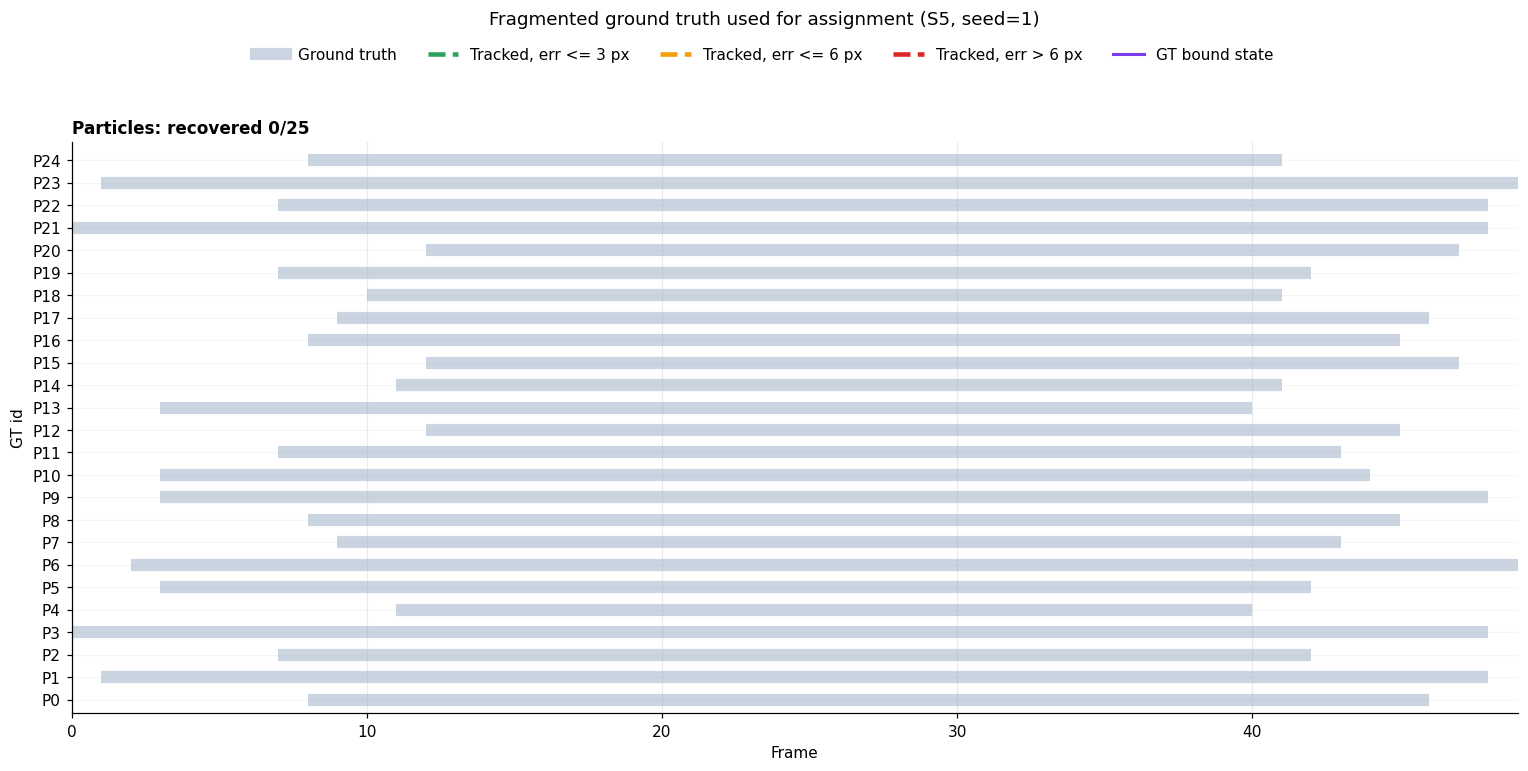

,n_gt_fragments,n_source_gt,mean_gt_length,median_gt_length,min_start_frame,max_start_frame,original_gt_count
0,25,25,38.24,37.0,0.0,12.0,25


Saved fragmented-GT visualization:
- C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results\CostExperiment_difficulty_intensity_fragmented_gt.png
- C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results\CostExperiment_difficulty_intensity_fragmented_gt.pdf


In [9]:
def make_visualization_item(seed=None, setup_index=None):
    seed = SEEDS[0] if seed is None else int(seed)
    setup_index = len(DIFFICULTY_SETUPS) - 1 if setup_index is None else int(setup_index)
    setup = DIFFICULTY_SETUPS[setup_index]
    return prepare_simulation_item(seed, setup, setup_index)

gt_viz_item = sim_cache[-1] if sim_cache else make_visualization_item()

fig_gt, _ = linear_trajectories_visualiser(
    [],
    gt_viz_item["sim"].trajectories_GT,
    show_unassigned=False,
    show_labels=False,
    title=(
        "Fragmented ground truth used for assignment "
        f"({gt_viz_item['setup']}, seed={gt_viz_item['seed']})"
    ),
    figsize=(14, 7),
    save_path=RESULT_PATHS["gt_viz_png"],
    return_fig=True,
)
fig_gt.savefig(RESULT_PATHS["gt_viz_pdf"], bbox_inches="tight")

display(pd.DataFrame([gt_viz_item["gt_info"]]))
print("Saved fragmented-GT visualization:")
print(f"- {RESULT_PATHS['gt_viz_png']}")
print(f"- {RESULT_PATHS['gt_viz_pdf']}")

## Recommendation tables

In [10]:
peak_summary = summarize_by_config(peak_df, "peak_config", "peak_objective")
traj_summary = summarize_by_config(traj_df, "traj_config", "traj_objective")

best_peak_name = peak_summary.iloc[0]["peak_config"]
best_traj_name = traj_summary.iloc[0]["traj_config"]
best_peak_spec = next(spec for spec in PEAK_COST_SPECS if spec["name"] == best_peak_name)
best_traj_spec = next(spec for spec in TRAJ_COST_SPECS if spec["name"] == best_traj_name)

recommendation_rows = []
for stage, name, spec, summary, config_col, objective_col, selection_metric in [
    ("peak2peak", best_peak_name, best_peak_spec, peak_summary, "peak_config", "peak_objective", PEAK_SELECTION_METRIC),
    ("traj2traj", best_traj_name, best_traj_spec, traj_summary, "traj_config", "traj_objective", TRAJ_SELECTION_METRIC),
]:
    row = summary[summary[config_col] == name].iloc[0].to_dict()
    row.update({"stage": stage, "selection_metric": selection_metric, "recommended_config": name, **spec})
    recommendation_rows.append(row)
recommendations = pd.DataFrame(recommendation_rows)
recommendations.to_csv(RESULT_PATHS["summary"], index=False)

print("Best peak-to-peak parameters")
print(
    f"  {best_peak_name}: "
    f"w_dist={best_peak_spec['distance']:.3f}, "
    f"w_int={best_peak_spec['intensity']:.3f}, "
    f"w_sigma={best_peak_spec['sigma']:.3f}, "
    f"mean HOTA={peak_summary.iloc[0]['hota_mean']:.3f}"
)
print("\nBest trajectory-to-trajectory parameters")
print(
    f"  {best_traj_name}: "
    f"w_pos={best_traj_spec['position']:.3f}, "
    f"w_len={best_traj_spec['length']:.3f}, "
    f"w_start={best_traj_spec['start_frame']:.3f}, "
    f"mean link F1={traj_summary.iloc[0]['link_f1_mean']:.3f}"
)

print("\nPeak-to-peak ranking by mean HOTA")
display(peak_summary[[
    "peak_config",
    "n",
    "hota_mean",
    "hota_ci95",
    "mota_mean",
    "motp_px_mean",
    "id_switches_mean",
    "fragmentations_mean",
    "mean_coverage_mean",
]])

print("Trajectory-to-trajectory ranking by mean link F1")
display(traj_summary[[
    "traj_config",
    "n",
    "link_f1_mean",
    "link_f1_ci95",
    "link_recall_mean",
    "mean_coverage_mean",
    "median_position_error_px_mean",
]])

Best peak-to-peak parameters
  dist_int_60_40: w_dist=0.600, w_int=0.400, w_sigma=0.000, mean HOTA=0.601

Best trajectory-to-trajectory parameters
  length_only: w_pos=0.000, w_len=1.000, w_start=0.000, mean link F1=0.721

Peak-to-peak ranking by mean HOTA


,peak_config,n,hota_mean,hota_ci95,mota_mean,motp_px_mean,id_switches_mean,fragmentations_mean,mean_coverage_mean
0,dist_int_60_40,10,0.600717,0.019066,0.348583,0.932109,34.5,43.6,0.770425
1,dist_sig_75_25,10,0.598804,0.026322,0.343787,0.937221,36.5,43.9,0.772341
2,dist_meta_50_40_10,10,0.589450,0.025438,0.335623,0.931138,37.2,42.9,0.772090
3,dist_int_75_25,10,0.586963,0.014791,0.340624,0.931822,37.0,41.1,0.769503
4,dist_meta_70_20_10,10,0.584073,0.028020,0.339347,0.933958,37.1,42.3,0.774157
5,dist_sig_90_10,10,0.581814,0.020131,0.334472,0.935170,37.5,41.9,0.772763
6,dist_sig_60_40,10,0.580024,0.023783,0.332868,0.937645,40.1,44.2,0.772282
7,dist_meta_80_10_10,10,0.575089,0.028965,0.331704,0.933711,37.3,41.9,0.773825
8,dist_int_90_10,10,0.574427,0.024089,0.333372,0.930707,37.7,41.5,0.768476
9,equal_all,10,0.562754,0.024831,0.320954,0.933971,44.7,44.0,0.770375


Trajectory-to-trajectory ranking by mean link F1


,traj_config,n,link_f1_mean,link_f1_ci95,link_recall_mean,mean_coverage_mean,median_position_error_px_mean
0,length_only,10,0.720927,0.027442,0.641410,0.770425,0.741498
1,pos_len_75_25,10,0.667033,0.027492,0.571762,0.770425,0.741498
2,pos_len_60_40,10,0.666938,0.029504,0.575479,0.770425,0.741498
3,equal_all,10,0.666108,0.026164,0.565850,0.770425,0.741498
4,pos_len_90_10,10,0.654522,0.027151,0.554072,0.770425,0.741498
5,pos_meta_70_20_10,10,0.645771,0.033800,0.548365,0.770425,0.741498
6,pos_meta_60_20_20,10,0.642964,0.029143,0.543901,0.770425,0.741498
7,pos_meta_80_10_10,10,0.635115,0.030956,0.534824,0.770425,0.741498
8,pos_start_60_40,10,0.613475,0.028658,0.500110,0.770425,0.741498
9,pos_start_75_25,10,0.603116,0.030707,0.492693,0.770425,0.741498


## Final metric panels

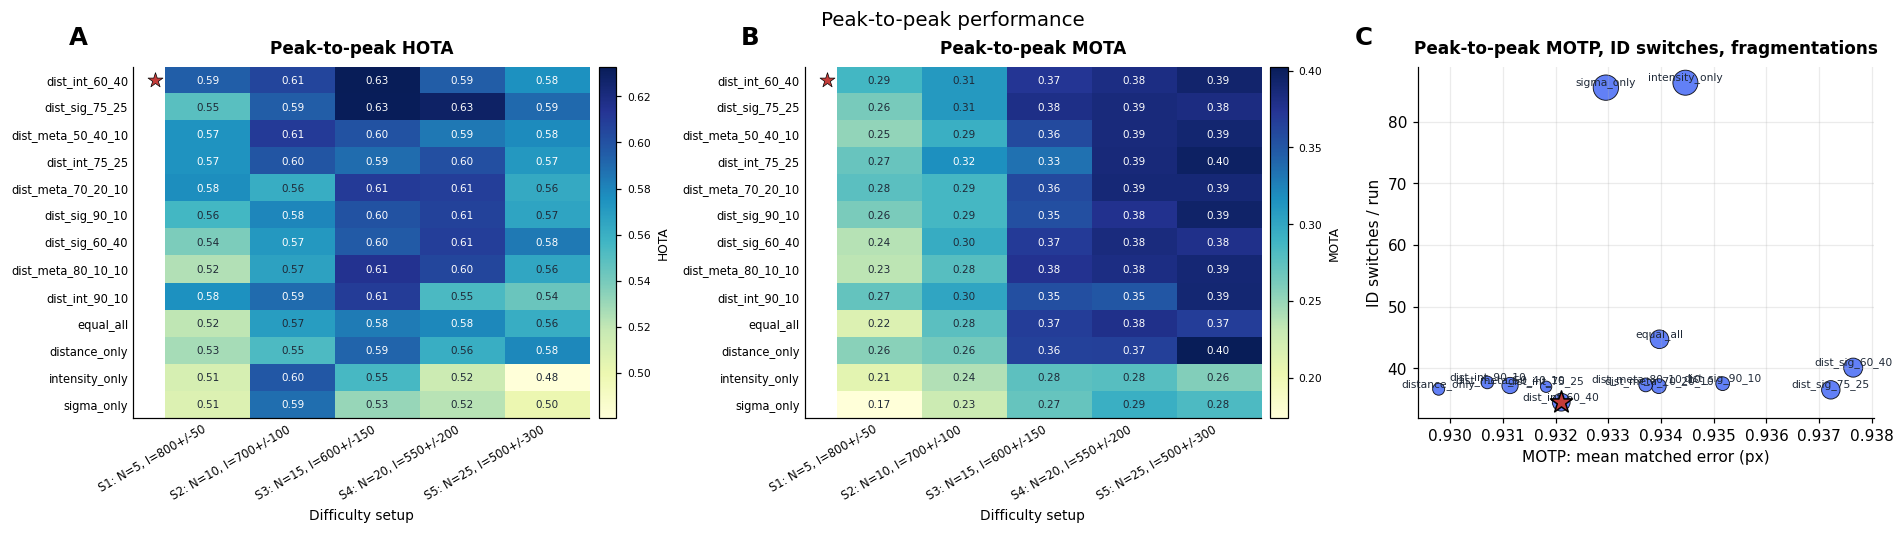

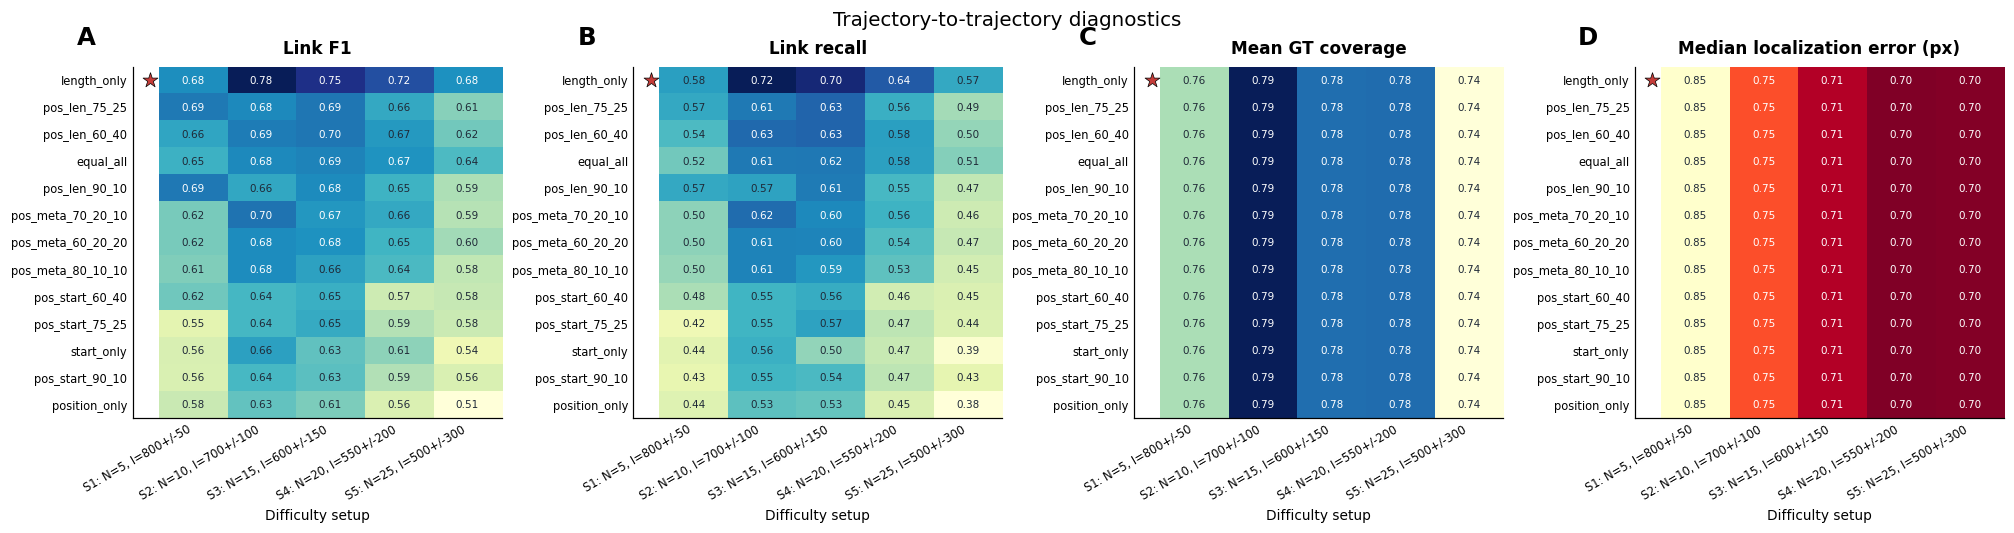

Saved final metric panels:
- C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results\CostExperiment_difficulty_intensity_tracking_metrics_peak.png
- C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results\CostExperiment_difficulty_intensity_tracking_metrics_traj.png


In [11]:
COLORS = {
    "best": "#C43C39",
    "text": "#1f2937",
    "grid": "#d1d5db",
}

def add_panel_label(ax, label):
    ax.text(
        -0.10,
        1.05,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="bottom",
        ha="right",
        color="black",
    )

def metric_matrix(df, summary, config_col, metric_col):
    order = summary[config_col].tolist()
    grouped = (
        df.groupby([config_col, "difficulty"])[metric_col]
        .mean()
        .unstack("difficulty")
        .reindex(index=order, columns=DIFFICULTY_LABELS)
    )
    return grouped

def heatmap_metric(ax, matrix, title, best_name, higher_better=True, fmt=".2f"):
    values = matrix.to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    vmin = float(finite.min()) if len(finite) else 0.0
    vmax = float(finite.max()) if len(finite) else 1.0
    cmap = "YlGnBu" if higher_better else "YlOrRd_r"
    im = ax.imshow(values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_title(title, fontsize=11, fontweight="semibold", pad=9)
    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_xticklabels(matrix.columns, rotation=30, ha="right", fontsize=7.5)
    ax.set_yticks(np.arange(matrix.shape[0]))
    ax.set_yticklabels(matrix.index, fontsize=7.5)
    ax.tick_params(length=0)

    if best_name in matrix.index:
        best_idx = list(matrix.index).index(best_name)
        ax.scatter(
            [-0.62],
            [best_idx],
            marker="*",
            s=105,
            color=COLORS["best"],
            edgecolor="black",
            linewidth=0.45,
            clip_on=False,
            zorder=4,
        )

    threshold = vmin + 0.60 * (vmax - vmin) if higher_better else vmin + 0.40 * (vmax - vmin)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = values[i, j]
            if not np.isfinite(val):
                label = "--"
                color = COLORS["text"]
            else:
                label = format(val, fmt)
                color = "white" if (val >= threshold if higher_better else val <= threshold) else COLORS["text"]
            ax.text(j, i, label, ha="center", va="center", fontsize=6.8, color=color)

    ax.set_xlabel("Difficulty setup", fontsize=9)
    return im

def scatter_tracking_events(ax, summary, config_col, best_name, title):
    x = summary["motp_px_mean"].to_numpy(dtype=float)
    y = summary["id_switches_mean"].to_numpy(dtype=float)
    sizes_raw = np.nan_to_num(summary["fragmentations_mean"].to_numpy(dtype=float), nan=0.0)
    if sizes_raw.max() > sizes_raw.min():
        sizes = 55 + 220 * (sizes_raw - sizes_raw.min()) / (sizes_raw.max() - sizes_raw.min())
    else:
        sizes = np.full_like(sizes_raw, 90.0)

    ax.scatter(x, y, s=sizes, color="#4c6ef5", edgecolor="black", alpha=0.88, linewidth=0.6)
    labels = summary[config_col].tolist()
    for xi, yi, label in zip(x, y, labels):
        if np.isfinite(xi) and np.isfinite(yi):
            ax.text(xi, yi, label, fontsize=7, ha="center", va="bottom", color=COLORS["text"])

    if best_name in labels:
        idx = labels.index(best_name)
        ax.scatter([x[idx]], [y[idx]], marker="*", s=230, color=COLORS["best"], edgecolor="black", zorder=5)

    ax.set_title(title, fontsize=11, fontweight="semibold", pad=9)
    ax.set_xlabel("MOTP: mean matched error (px)")
    ax.set_ylabel("ID switches / run")
    ax.grid(alpha=0.25)

peak_hota_matrix = metric_matrix(peak_df, peak_summary, "peak_config", "hota")
peak_mota_matrix = metric_matrix(peak_df, peak_summary, "peak_config", "mota")

fig, axes = plt.subplots(1, 3, figsize=(17.2, 4.6), constrained_layout=True)
im0 = heatmap_metric(axes[0], peak_hota_matrix, "Peak-to-peak HOTA", best_peak_name)
im1 = heatmap_metric(axes[1], peak_mota_matrix, "Peak-to-peak MOTA", best_peak_name)
scatter_tracking_events(axes[2], peak_summary, "peak_config", best_peak_name, "Peak-to-peak MOTP, ID switches, fragmentations")

for label, ax in zip("ABC", axes):
    add_panel_label(ax, label)
for im, ax, label in [(im0, axes[0], "HOTA"), (im1, axes[1], "MOTA")]:
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label(label, fontsize=8)
    cbar.ax.tick_params(labelsize=7)

fig.suptitle("Peak-to-peak performance", fontsize=13, y=1.02)
fig.savefig(RESULT_PATHS["peak_figure_png"], bbox_inches="tight")
plt.show()

traj_metrics = [
    ("link_f1", "Link F1", True, ".2f"),
    ("link_recall", "Link recall", True, ".2f"),
    ("mean_coverage", "Mean GT coverage", True, ".2f"),
    ("median_position_error_px", "Median localization error (px)", False, ".2f"),
]
fig2, axes2 = plt.subplots(1, 4, figsize=(18.2, 4.6), constrained_layout=True)
for ax, (metric, title, higher_better, fmt) in zip(axes2, traj_metrics):
    matrix = metric_matrix(traj_df, traj_summary, "traj_config", metric)
    heatmap_metric(ax, matrix, title, best_traj_name, higher_better=higher_better, fmt=fmt)
for label, ax in zip("ABCD", axes2):
    add_panel_label(ax, label)

fig2.suptitle("Trajectory-to-trajectory diagnostics", fontsize=13, y=1.02)
fig2.savefig(RESULT_PATHS["traj_figure_png"], bbox_inches="tight")
plt.show()

print("Saved final metric panels:")
print(f"- {RESULT_PATHS['peak_figure_png']}")
print(f"- {RESULT_PATHS['traj_figure_png']}")

## Visualize best-ranked trajectories

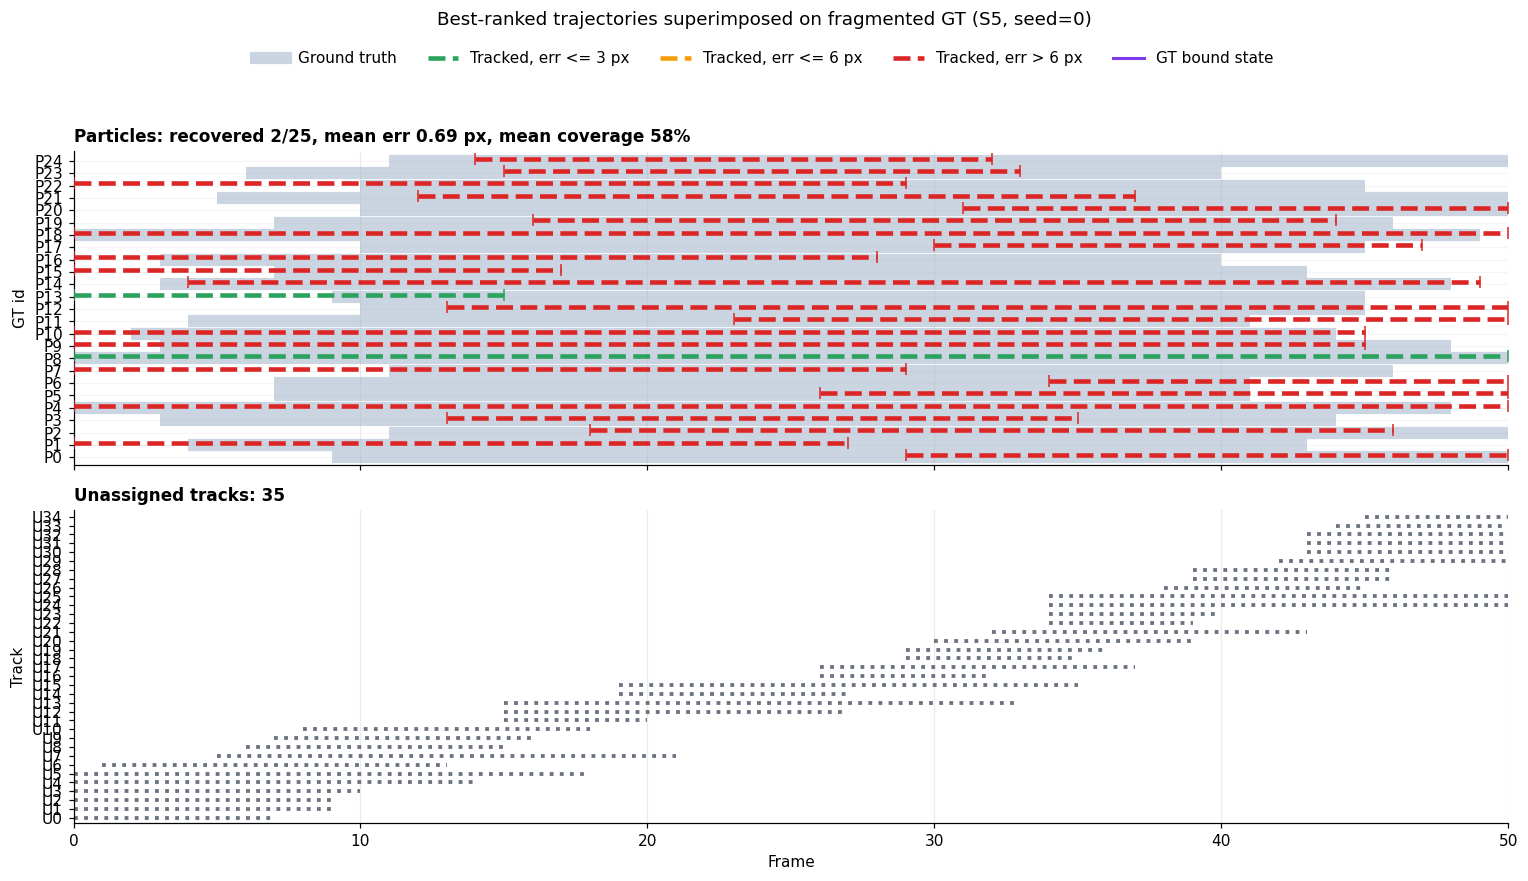

,hota,mota,link_f1,link_recall,mean_coverage,median_position_error_px,id_switches,fragmentations
0,0.595921,0.428283,0.68256,0.563731,0.735569,0.707212,62,83


Saved best-trajectory visualization:
- C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results\CostExperiment_difficulty_intensity_best_trajectories_vs_gt.png
- C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results\CostExperiment_difficulty_intensity_best_trajectories_vs_gt.pdf


In [12]:
def run_best_configuration_for_visualization(seed=None, setup_index=None):
    item = make_visualization_item(seed=seed, setup_index=setup_index)
    trajectories, _, _, _ = track_from_peaks(
        item["peaks"],
        item["sim"].trajectories_GT,
        max_distance=TRACKING_KWARGS["max_distance"],
        min_length=TRACKING_KWARGS["min_length"],
        max_gap=TRACKING_KWARGS["max_gap"],
        algo_peak2peak=TRACKING_KWARGS["algo_peak2peak"],
        cost_func_peak2peak=build_peak_cost(best_peak_spec),
        algo_traj2traj=TRACKING_KWARGS["algo_traj2traj"],
        cost_func_traj2traj=build_traj_cost(best_traj_spec),
        verbose_assignment=False,
    )
    return item, trajectories

best_viz_item, best_viz_trajectories = run_best_configuration_for_visualization()

fig_best, _ = linear_trajectories_visualiser(
    best_viz_trajectories,
    best_viz_item["sim"].trajectories_GT,
    show_unassigned=True,
    show_labels=False,
    title=(
        "Best-ranked trajectories superimposed on fragmented GT "
        f"({best_viz_item['setup']}, seed={best_viz_item['seed']})"
    ),
    figsize=(14, 8),
    save_path=RESULT_PATHS["best_viz_png"],
    return_fig=True,
)
fig_best.savefig(RESULT_PATHS["best_viz_pdf"], bbox_inches="tight")

best_viz_metrics = score_labeled_trajectories(
    best_viz_trajectories,
    best_viz_item["sim"].trajectories_GT,
    runtime_s=np.nan,
)
display(pd.DataFrame([best_viz_metrics])[[
    "hota",
    "mota",
    "link_f1",
    "link_recall",
    "mean_coverage",
    "median_position_error_px",
    "id_switches",
    "fragmentations",
]])

print("Saved best-trajectory visualization:")
print(f"- {RESULT_PATHS['best_viz_png']}")
print(f"- {RESULT_PATHS['best_viz_pdf']}")

## Reusable recommended cost objects

In [13]:
recommended_peak2peak_cost = build_peak_cost(best_peak_spec)
recommended_traj2traj_cost = build_traj_cost(best_traj_spec)

print("Use these objects in sim.track(...):")
print("cost_func_peak2peak=recommended_peak2peak_cost")
print("cost_func_traj2traj=recommended_traj2traj_cost")

Use these objects in sim.track(...):
cost_func_peak2peak=recommended_peak2peak_cost
cost_func_traj2traj=recommended_traj2traj_cost
